In [75]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import copy
import joblib
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from xgboost import XGBRegressor

In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
warnings.filterwarnings("ignore")

**<font color = blue size=6>
1.Data preprocessing and Exploratory Data Analytics
</font>**

In [3]:
data = pd.read_excel('d:/增量预测/增量数据rm.xlsx')

In [4]:
data

,C,N,Vb,Vc,Fat,cellulose,Weightgain
0,20,20,1.0,1.0,10.0,58.0,0.0881
1,5,5,0.1,0.1,2.5,89.8,0.1291
2,10,40,0.1,0.0,5.0,48.9,0.0581
3,0,5,0.5,1.0,15.0,93.5,0.0531
4,0,40,1.0,0.5,2.5,58.5,0.1780
...,...,...,...,...,...,...,...
1031,40,0,0.1,0.5,10.0,59.4,0.0514
1032,10,20,3.0,0.0,2.5,67.0,0.1087
1033,10,40,1.0,1.0,5.0,48.9,0.1907
1034,20,10,0.1,0.0,15.0,69.9,0.0260


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   C           1036 non-null   int64  
 1   N           1036 non-null   int64  
 2   Vb          1036 non-null   float64
 3   Vc          1036 non-null   float64
 4   Fat         1036 non-null   float64
 5   cellulose   1036 non-null   float64
 6   Weightgain  1036 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 56.8 KB


In [199]:
missing_values = data.isnull().sum()  # Count missing values per column
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 C             0
N             0
Vb            0
Vc            0
Fat           0
cellulose     0
Weightgain    0
dtype: int64


In [203]:
if df.isnull().values.any():
    print("Dataset contains missing values. Proceeding to remove them.")
    df_cleaned = df.dropna()
    print("Missing values after removal:\n", df_cleaned.isnull().sum().sum())
else:
    print("No missing values found. No action needed.")

#df_cleaned.to_csv('cleaned_dataset.csv', index=False)
#print("Data cleaning complete. Cleaned dataset saved.")

No missing values found. No action needed.


In [6]:
data.describe()

,C,N,Vb,Vc,Fat,cellulose,Weightgain
count,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000
mean,14.700772,19.700772,0.830792,0.929151,6.575772,64.560328,0.104876
std,13.836772,16.067708,1.124049,1.097718,5.582824,19.637022,0.051503
min,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.015900
25%,5.000000,5.000000,0.100000,0.100000,2.500000,48.900000,0.059700
50%,10.000000,20.000000,0.500000,0.500000,5.000000,59.400000,0.101800
75%,20.000000,40.000000,1.000000,1.000000,10.000000,81.000000,0.143325
max,60.000000,40.000000,5.000000,5.000000,30.000000,100.000000,0.239600


**<font color = blue size=6>
1.1 Data normalization and distribution
</font>**

In [9]:
df = pd.DataFrame(data)

In [10]:
scaler = StandardScaler()
X = df.drop('Weightgain', axis=1)
y = df['Weightgain']
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df['Weightgain'] = y
X_scaled_df.to_excel('d:/增量预测/scaled-weight.xlsx', index=False)
Scaled_data = X_scaled_df

In [11]:
Scaled_data

,C,N,Vb,Vc,Fat,cellulose,Weightgain
0,0.383166,0.018632,0.150608,0.064574,0.613647,-0.334241,0.0881
1,-0.701425,-0.915368,-0.650456,-0.755705,-0.730408,1.285931,0.1291
2,-0.339894,1.263966,-0.650456,-0.846847,-0.282390,-0.797875,0.0581
3,-1.062955,-0.915368,-0.294428,0.064574,1.509683,1.474442,0.0531
4,-1.062955,1.263966,0.150608,-0.391137,-0.730408,-0.308767,0.1780
...,...,...,...,...,...,...,...
1031,1.829288,-1.226702,-0.650456,-0.391137,0.613647,-0.262913,0.0514
1032,-0.339894,0.018632,1.930749,-0.846847,-0.730408,0.124298,0.1087
1033,-0.339894,1.263966,0.150608,0.064574,-0.282390,-0.797875,0.1907
1034,0.383166,-0.604035,-0.650456,-0.846847,1.509683,0.272050,0.0260


In [12]:
Scaled_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   C           1036 non-null   float64
 1   N           1036 non-null   float64
 2   Vb          1036 non-null   float64
 3   Vc          1036 non-null   float64
 4   Fat         1036 non-null   float64
 5   cellulose   1036 non-null   float64
 6   Weightgain  1036 non-null   float64
dtypes: float64(7)
memory usage: 56.8 KB


In [13]:
Scaled_data.describe()

,C,N,Vb,Vc,Fat,cellulose,Weightgain
count,1.036000e+03,1.036000e+03,1.036000e+03,1.036000e+03,1.036000e+03,1.036000e+03,1036.000000
mean,-1.200241e-17,8.573151e-18,7.029984e-17,9.773392e-17,4.115112e-17,-1.045924e-16,0.104876
std,1.000483e+00,1.000483e+00,1.000483e+00,1.000483e+00,1.000483e+00,1.000483e+00,0.051503
min,-1.062955e+00,-1.226702e+00,-7.394632e-01,-8.468470e-01,-1.178427e+00,-2.575989e+00,0.015900
25%,-7.014250e-01,-9.153684e-01,-6.504561e-01,-7.557049e-01,-7.304082e-01,-7.978752e-01,0.059700
50%,-3.398945e-01,1.863192e-02,-2.944278e-01,-3.911367e-01,-2.823899e-01,-2.629126e-01,0.101800
75%,3.831665e-01,1.263966e+00,1.506075e-01,6.457362e-02,6.136467e-01,8.375818e-01,0.143325
max,3.275410e+00,1.263966e+00,3.710891e+00,3.710256e+00,4.197793e+00,1.805609e+00,0.239600


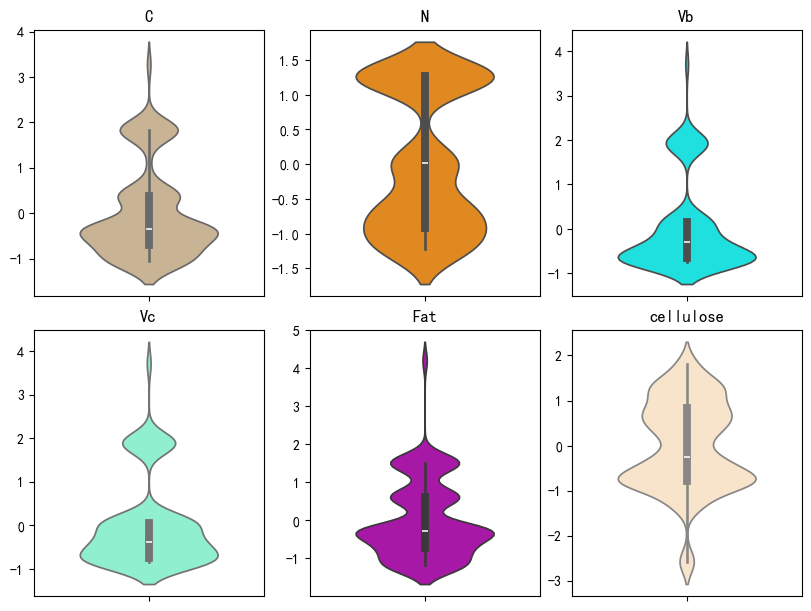

In [14]:
column = list(Scaled_data.columns)[:-1]
fig, ax =plt.subplots(2,3,constrained_layout=True, figsize=(8,6))
colors = ['tan','darkorange','cyan','#7FFFD4','m','#FFE4C4','#FFEBCD','#0000FF','#8A2BE2','#A52A2A','#DEB887','#5F9EA0',
          '#7FFF00','#F08080','#FFE4C4','r']
a = 1
b = 0
for i in range(len(column)):
    if b!=0 and b%3 == 0:
        b = 0
        a += 1
    pic = sns.violinplot(Scaled_data[column[i]].tolist(),ax=ax[a-1,b],color=colors[i],width=0.6)
    pic.set_title(column[i])
    b+=1
#fig.savefig('d:/增量预测/小提琴图.png', dpi=600)

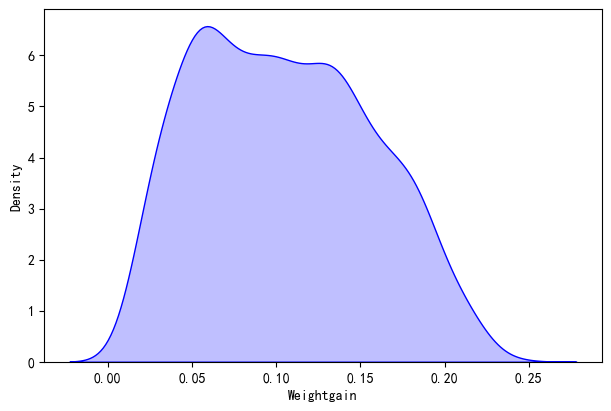

In [15]:
fig, ax =plt.subplots(1,1,constrained_layout=True, figsize=(6,4))
sns.kdeplot(Scaled_data['Weightgain'], color='b', shade=True)
#fig.savefig('d:/增量预测/标签分布.png', dpi=600)
data = Scaled_data

**<font color = blue size=6>
1.2 Correlation analysis of scaled data
</font>**

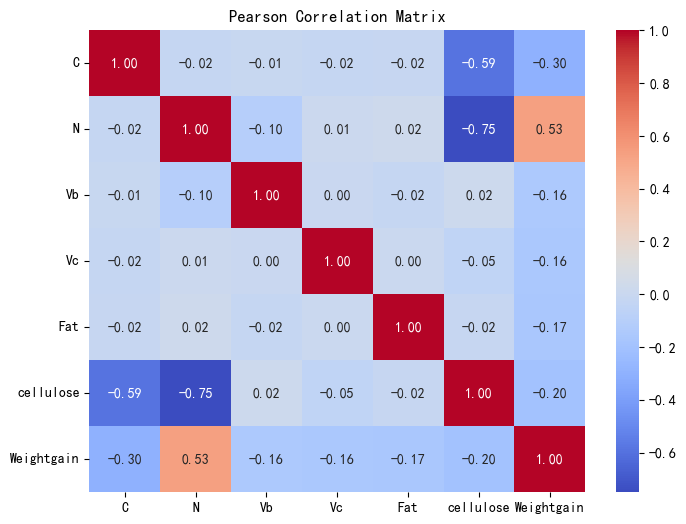

In [16]:
# Pearson correlation analysis
corr = data.corr()

# 绘制相关性矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.savefig('d:/增量预测/相关性分析.png', dpi=1200)
plt.show()

**<font color = blue size=6>
2. Built machine learning models
</font>**

**<font color = blue size=5>
2.1 Data spliting
</font>**

In [240]:
#### Divide dataset
train_X,test_X,train_Y,test_Y = train_test_split(data.iloc[:,:-1],data.iloc[:,-1],train_size=0.8,random_state=14)
train_X.to_excel('d:/增量预测/train_X.xlsx', index=False)

In [72]:
columns = train_X.columns.to_list()

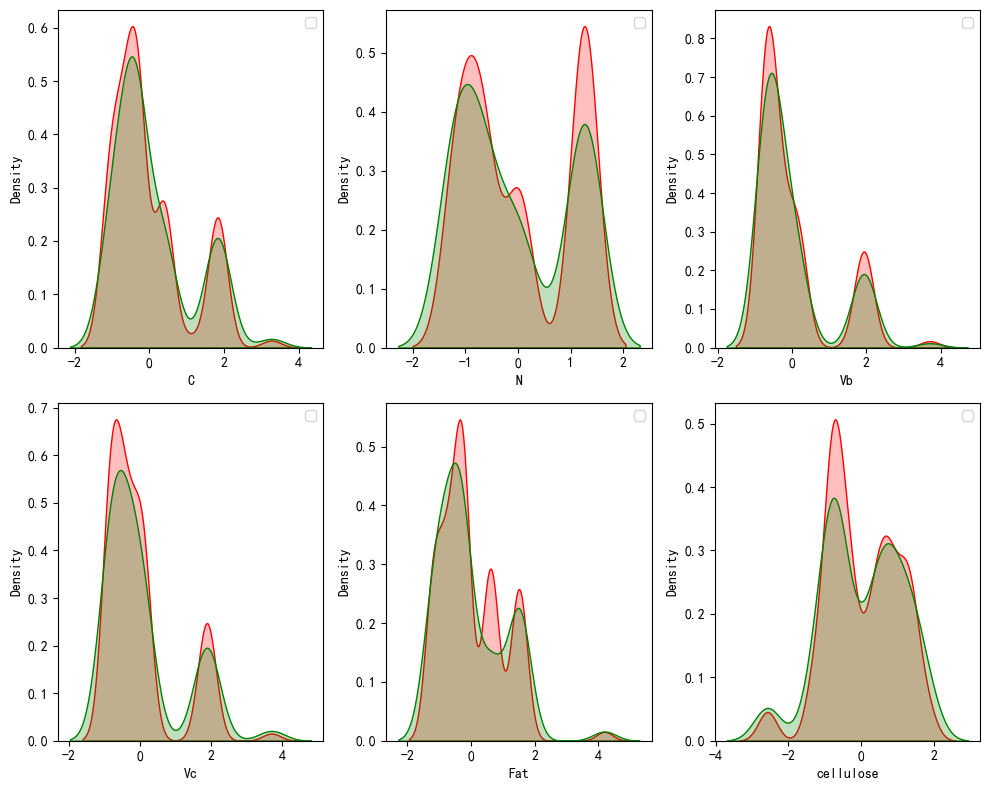

In [73]:
### Check the distribution of Train data and Test data set
fig,ax = plt.subplots(2,3,figsize=(10, 8))
for i in range(2):
    for j in range(3):
        pic = sns.kdeplot(train_X[columns[i*3+j]], shade=True, color="r",ax=ax[i,j])
        pic = sns.kdeplot(test_X[columns[i*3+j]], shade=True, color="g",ax=ax[i,j])
        pic.set_xlabel(columns[i*3+j],fontsize=10)
        ax[i, j].legend(loc='upper right')

fig.savefig('d:/增量预测/训练集_测试集对比.png', dpi=600)
plt.tight_layout()
####Train set : Red
####Test set : Green

In [234]:
train_X


,C,N,Vb,Vc,Fat,cellulose
583,-0.339894,-0.915368,-0.739463,1.887415,0.613647,0.888531
1012,-0.701425,-0.915368,-0.650456,-0.755705,-0.730408,1.285931
814,1.829288,0.018632,-0.294428,-0.755705,-1.178427,-1.281889
457,-0.339894,0.018632,1.930749,-0.846847,-0.730408,0.124298
276,-0.339894,-0.604035,-0.294428,-0.391137,-0.282390,0.735684
...,...,...,...,...,...,...
668,0.383166,0.018632,0.150608,0.064574,0.613647,-0.334241
746,-0.701425,-0.604035,0.150608,1.887415,-1.178427,0.837582
327,-0.339894,0.018632,1.930749,-0.846847,-0.730408,0.124298
406,1.829288,0.018632,-0.294428,-0.755705,-1.178427,-1.281889


**<font color = blue size=5>
2.2.1 Decision tree (default parameters)
</font>**

In [38]:
dt_model = DecisionTreeRegressor()  ####Decision tree with default parameter
dt_model.fit(train_X, train_Y)
y_pred_dt = dt_model.predict(test_X)

In [39]:
print('Decision tree——R2：{}'.format(r2_score(test_Y,y_pred_dt)))
print('Decision tree——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,y_pred_dt))))
print('Decision tree——MAE：{}'.format(mean_absolute_error(test_Y,y_pred_dt)))

Decision tree——R2：0.808285105009045
Decision tree——RMSE：0.022397604938238315
Decision tree——MAE：0.018059929926081523


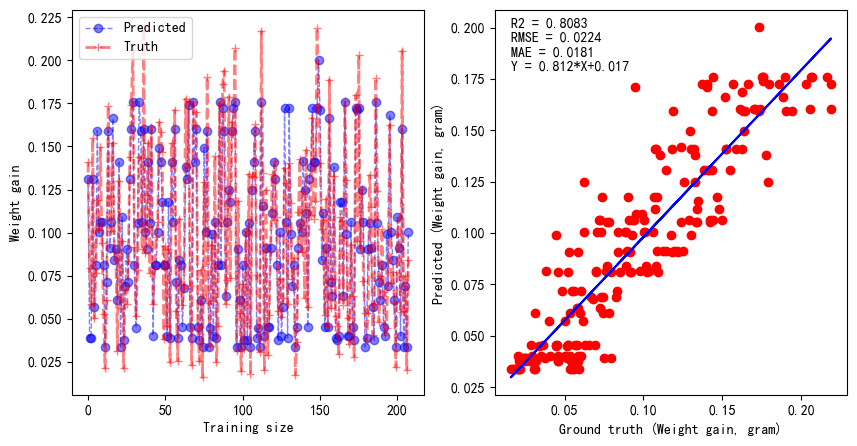

In [40]:
x = [i for i in range(len(y_pred_dt))]
# 绘制图像
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, y_pred_dt, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='Truth', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain')

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(y_pred_dt.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),y_pred_dt.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(y_pred_dt.tolist()), f'R2 = {r2_score(test_Y,y_pred_dt):.4f}')
ax[1].text(min(test_Y.tolist()), max(y_pred_dt.tolist())-0.007, f'RMSE = {np.sqrt(mean_squared_error(test_Y,y_pred_dt)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_dt.tolist())-0.014, f'MAE = {mean_absolute_error(test_Y,y_pred_dt):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_dt.tolist())-0.021, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
#plt.savefig('d:/增量预测/预测结果图_DT.svg',format='svg',dpi= 1200)
plt.show()   ####Visualize the performance of default DT model.

**<font color = blue size=5>
2.2.2 Decision tree (Optimised by Grid Search)
</font>**

In [41]:
####Grid search method
param_grid = { 'max_depth':np.arange(1,30,1),
              'max_features':np.arange(1,10,1),
             'min_samples_split':np.arange(1,10,1),
              'min_samples_leaf':np.arange(1,10,1),
             }

rfr = DecisionTreeRegressor()
reg = GridSearchCV(rfr,
                   param_grid,
                   scoring='r2',
                   cv=3,verbose = 1).fit(train_X, train_Y)

best_alpha = reg.best_params_
best_score = reg.best_score_

Fitting 3 folds for each of 21141 candidates, totalling 63423 fits


In [42]:
best_alpha   ####show the best parameters

{'max_depth': 12,
 'max_features': 5,
 'min_samples_leaf': 2,
 'min_samples_split': 5}

In [43]:
best_score

0.7080109642646603

In [54]:
#####Generate DT model with Grid search optimized parameters
t_model = DecisionTreeRegressor(max_depth=12,max_features=5,min_samples_leaf=2,min_samples_split=5)
dt_model.fit(train_X, train_Y)
y_pred_dt = dt_model.predict(test_X)

In [56]:
print('Decision tree_grid search——R2：{}'.format(r2_score(test_Y,y_pred_dt)))
print('Decision tree_grid search——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,y_pred_dt))))
print('Decision tree_grid search——MAE：{}'.format(mean_absolute_error(test_Y,y_pred_dt)))

Decision tree_grid search——R2：0.808285105009045
Decision tree_grid search——RMSE：0.022397604938238315
Decision tree_grid search——MAE：0.018059929926081523


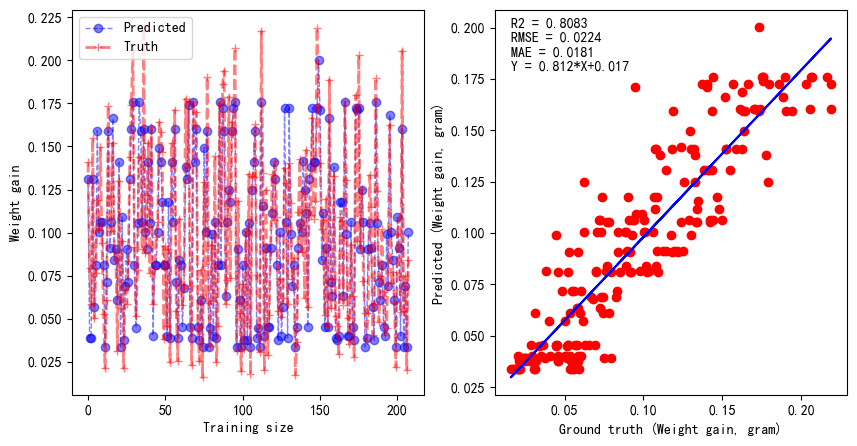

In [57]:
x = [i for i in range(len(y_pred_dt))]
# 绘制图像
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, y_pred_dt, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='Truth', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain')

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(y_pred_dt.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),y_pred_dt.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(y_pred_dt.tolist()), f'R2 = {r2_score(test_Y,y_pred_dt):.4f}')
ax[1].text(min(test_Y.tolist()), max(y_pred_dt.tolist())-0.007, f'RMSE = {np.sqrt(mean_squared_error(test_Y,y_pred_dt)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_dt.tolist())-0.014, f'MAE = {mean_absolute_error(test_Y,y_pred_dt):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_dt.tolist())-0.021, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
#plt.savefig('d:/增量预测/预测结果图_DT.svg',format='svg',dpi= 1200)
plt.show()

**<font color = blue size=5>
2.2.3 Decision tree (Optimised by Grey Wolf Optimization (GWO) method)
</font>**

In [226]:
########Build GWO algorithm###

def initial(pop, dim, ub, lb):
    X = np.zeros([pop, dim])
    for i in range(pop):
        for j in range(dim):
            X[i, j] = int(random.random() * (ub[j] - lb[j]) + lb[j])

    return X, lb, ub


def BorderCheck(X, ub, lb, pop, dim):
    for i in range(pop):
        for j in range(dim):
            if X[i, j] < lb[j]:
                X[i, j] = lb[j]
            elif X[i, j] > ub[j]:
                X[i, j] = ub[j]
    return X


def CaculateFitness(X, fun, train_X, vali_X, train_Y, vali_Y):
    pop = X.shape[0]
    fitness = np.zeros([pop, 1])
    for i in range(pop):
        fitness[i] = fun(X[i, :], train_X, vali_X, train_Y, vali_Y)
    return fitness


def SortFitness(Fit):
    fitness = np.sort(Fit, axis=0)
    index = np.argsort(Fit, axis=0)
    return fitness, index


def SortPosition(X, index):
    Xnew = np.zeros(X.shape)
    for i in range(X.shape[0]):
        Xnew[i, :] = X[index[i], :]
    return Xnew


###GWO algorithm

def GWO(pop, dim, lb, ub, MaxIter, fun, df1,df2,df3,df4):
    Alpha_pos = np.zeros([1, dim])
    Alpha_score = float("-inf")
    Beta_pos = np.ones([1, dim])
    Beta_score = float("-inf")
    Delta_pos = np.ones([1, dim])
    Delta_score = float("-inf")


    X, lb, ub = initial(pop, dim, ub, lb)  
    fitness = CaculateFitness(X, fun, df1,df2,df3,df4)  
    indexBest = np.argmax(fitness)
    GbestScore = copy.copy(fitness[indexBest])
    GbestPositon = np.zeros([1, dim])
    GbestPositon[0, :] = copy.copy(X[indexBest, :])
    Curve = np.zeros([MaxIter, 1])
    for t in range(MaxIter):

        for i in range(pop):
            fitValue = fun(X[i, :], df1,df2,df3,df4)
            if fitValue > Alpha_score:
                Alpha_score = copy.copy(fitValue)
                Alpha_pos[0, :] = copy.copy(X[i, :])

            if fitValue < Alpha_score and fitValue > Beta_score:
                Beta_score = copy.copy(fitValue)
                Beta_pos[0, :] = copy.copy(X[i, :])

            if fitValue < Alpha_score and fitValue < Beta_score and fitValue > Delta_score:
                Delta_score = copy.copy(fitValue)
                Delta_pos[0, :] = copy.copy(X[i, :])

        a = 2 - t * (2 / MaxIter)
        for i in range(pop):
            for j in range(dim):
                r1 = random.random()
                r2 = random.random()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2

                D_alpha = np.abs(C1 * Alpha_pos[0, j] - X[i, j])
                X1 = Alpha_pos[0, j] - A1 * D_alpha

                r1 = random.random()
                r2 = random.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2

                D_beta = np.abs(C2 * Beta_pos[0, j] - X[i, j])
                X2 = Beta_pos[0, j] - A2 * D_beta

                r1 = random.random()
                r2 = random.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_beta = np.abs(C3 * Delta_pos[0, j] - X[i, j])
                X3 = Delta_pos[0, j] - A3 * D_beta

                X[i, j] = (X1 + X2 + X3) / 3

        X = BorderCheck(X, ub, lb, pop, dim) 
        fitness = CaculateFitness(X, fun, df1,df2,df3,df4)  
        indexBest = np.argmax(fitness)
        if fitness[indexBest] >= GbestScore:  
            GbestScore = copy.copy(fitness[indexBest])
            GbestPositon[0, :] = copy.copy(X[indexBest, :])
        Curve[t] = GbestScore

    return GbestScore, GbestPositon, Curve


def fun1(X, train_X, vali_X, train_Y, vali_Y):
    model = DecisionTreeRegressor(max_depth=int(X[0]),max_features=int(X[1]),min_samples_leaf=int(X[2]),
                                  min_samples_split=int(X[3])
                                  )
    
    model.fit(train_X, train_Y)
    Y_pred = model.predict(vali_X)
    r2_score_res = r2_score(vali_Y, Y_pred)

    return r2_score_res


##### Main of GWO algorithm
# set parameters
pop = 10  # population
MaxIter = 500  # max iteration
dim = 4  # dimension
lb = np.array([1, 1, 1,2])  # upper border
ub = np.array([30, 10, 10, 10])  # lower border

fobj = fun1

GbestScore, GbestPositon, Curve = GWO(pop, dim, lb, ub, MaxIter, fobj, train_X, test_X, train_Y, test_Y)
print('The best parameter is：{}'.format(GbestPositon))
###output: [max_depth, max_features, min_samples_leaf, in_samples_split]

The best parameter is：[[13.34849714  1.95000192  2.81319702  6.00329043]]


In [227]:
####Generate GWO adjusted DT model
dt_GWO_model = DecisionTreeRegressor(max_depth=int(GbestPositon[0][0]),max_features=int(GbestPositon[0][1]),min_samples_leaf=int(GbestPositon[0][2]),min_samples_split=int(GbestPositon[0][3]))
dt_GWO_model.fit(train_X, train_Y)
y_pred_dt_GWO = dt_GWO_model.predict(test_X)
print('max_depth: ', int(GbestPositon[0][0]))
print('max_features: ', int(GbestPositon[0][1]))
print('min_samples_leaf: ', int(GbestPositon[0][2]))
print('min_samples_split: ', int(GbestPositon[0][3]))

max_depth:  13
max_features:  1
min_samples_leaf:  2
min_samples_split:  6


In [182]:
r2_sco = r2_score(test_Y, y_pred_dt_GWO)
mae = mean_absolute_error(test_Y, y_pred_dt_GWO)
rmse = np.sqrt(mean_squared_error(test_Y,y_pred_dt_GWO))

print('Decision tree_GWO——R2：{}'.format(r2_sco))
print('Decision tree_GWO——RMSE：{}'.format(rmse))
print('Decision tree_GWO——MAE：{}'.format(mae))


Decision tree_GWO——R2：0.8072553696871421
Decision tree_GWO——RMSE：0.022457675174640694
Decision tree_GWO——MAE：0.01814959217559671


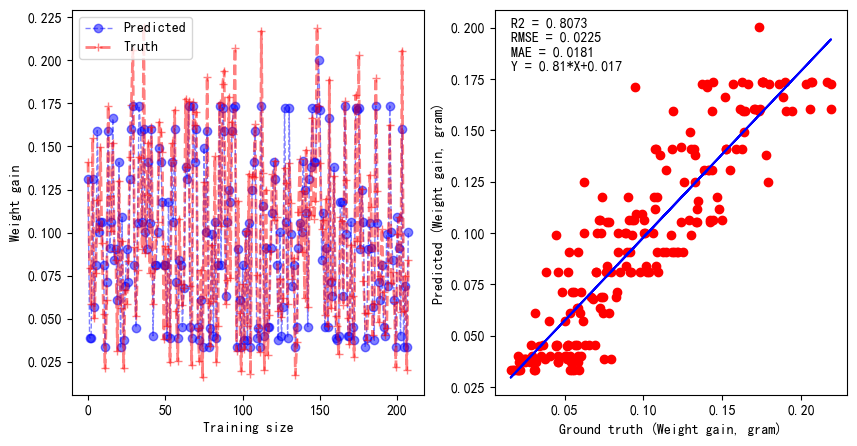

In [183]:
x = [i for i in range(len(y_pred_dt_GWO))]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, y_pred_dt_GWO, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='Truth', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain')

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(y_pred_dt_GWO.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),y_pred_dt_GWO.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(y_pred_dt_GWO.tolist()), f'R2 = {r2_score(test_Y,y_pred_dt_GWO):.4f}')
ax[1].text(min(test_Y.tolist()), max(y_pred_dt_GWO.tolist())-0.007, f'RMSE = {np.sqrt(mean_squared_error(test_Y,y_pred_dt_GWO)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_dt_GWO.tolist())-0.014, f'MAE = {mean_absolute_error(test_Y,y_pred_dt_GWO):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_dt_GWO.tolist())-0.021, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
plt.savefig('d:/增量预测/预测结果图_DT_GWO.svg',format='svg',dpi= 1200)
plt.show()   ####Visualize GWO adjusted DT model

**<font color = blue size=5>
2.3.1 Random forest model (defalut)
</font>**

In [208]:
model = RandomForestRegressor()
model.fit(train_X, train_Y)
rf_pre = model.predict(test_X)

In [209]:

print('RF——R2：{}'.format(r2_score(test_Y,rf_pre)))
print('RF——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,rf_pre))))
print('RF——MAE：{}'.format(mean_absolute_error(test_Y,rf_pre)))
#print(round(r2_score(test_Y,rf_pre),2))

RF——R2：0.8083515134045784
RF——RMSE：0.022393725433114776
RF——MAE：0.018069756782508474


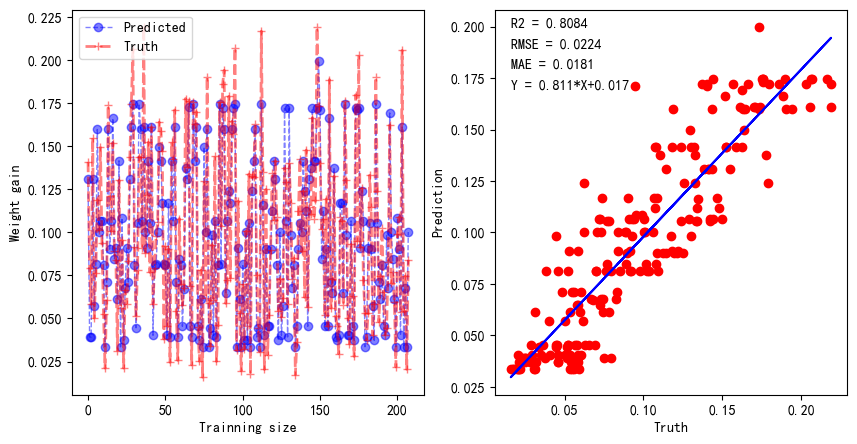

In [211]:
x = [i for i in range(len(rf_pre))]
# Visualization
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, rf_pre, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='Truth', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Trainning size')
ax[0].set_ylabel('Weight gain')

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(rf_pre.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),rf_pre.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(rf_pre.tolist()), f'R2 = {r2_score(test_Y, rf_pre):.4f}')
ax[1].text(min(test_Y.tolist()), max(rf_pre.tolist())-0.01, f'RMSE = {np.sqrt(mean_squared_error(test_Y,rf_pre)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(rf_pre.tolist())-0.02, f'MAE = {mean_absolute_error(test_Y,rf_pre):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(rf_pre.tolist())-0.03, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Truth')
ax[1].set_ylabel('Prediction')
#plt.savefig('d:/增量预测/预测结果图_RF.svg',format='svg',dpi=1200)
plt.show()

**<font color = blue size=5>
2.3.2 Random forest model (Optimised by Grid search)
</font>**

In [212]:
#Grid search
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10,20],
    'min_samples_leaf': [1, 5, 10,15,20],
    'max_features': np.arange(1,10,1),
}
# 网格搜索方式
rfr = RandomForestRegressor()
grid_search = GridSearchCV(rfr,
                   param_grid,
                   scoring='r2',
                   cv=3,verbose = 1).fit(train_X, train_Y)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Fitting 3 folds for each of 2880 candidates, totalling 8640 fits
Best parameters: {'max_depth': 20, 'max_features': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Best score: 0.7079437176993953


In [213]:
model = RandomForestRegressor(n_estimators=50,max_depth=20,max_features=5,min_samples_leaf=1,min_samples_split=10)
model.fit(train_X, train_Y)
rf_pre = model.predict(test_X)

In [214]:
print('RF——R2：{}'.format(r2_score(test_Y,rf_pre)))
print('RF——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,rf_pre))))
print('RF——MAE：{}'.format(mean_absolute_error(test_Y,rf_pre)))
#print(round(r2_score(test_Y,rf_pre),2))

RF——R2：0.8087747351790592
RF——RMSE：0.022368985476851455
RF——MAE：0.01800144229868476


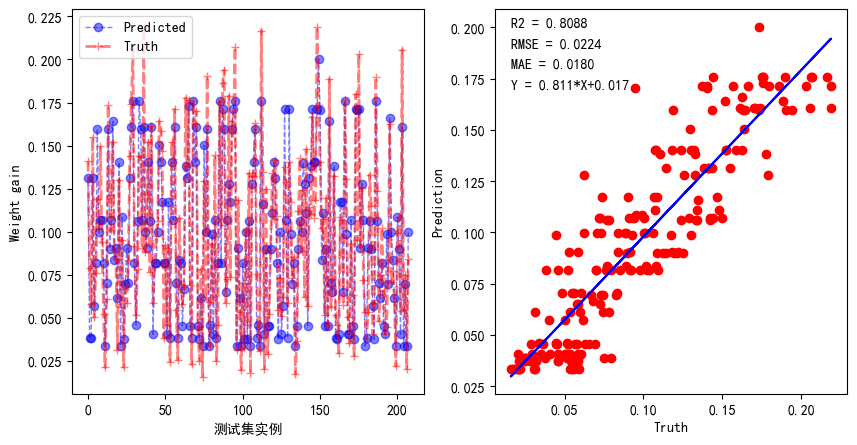

In [215]:
x = [i for i in range(len(rf_pre))]
# 绘制图像
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, rf_pre, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='Truth', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('测试集实例')
ax[0].set_ylabel('Weight gain')

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(rf_pre.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),rf_pre.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(rf_pre.tolist()), f'R2 = {r2_score(test_Y, rf_pre):.4f}')
ax[1].text(min(test_Y.tolist()), max(rf_pre.tolist())-0.01, f'RMSE = {np.sqrt(mean_squared_error(test_Y,rf_pre)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(rf_pre.tolist())-0.02, f'MAE = {mean_absolute_error(test_Y,rf_pre):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(rf_pre.tolist())-0.03, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Truth')
ax[1].set_ylabel('Prediction')
#plt.savefig('d:/增量预测/预测结果图_RF.svg',format='svg',dpi=1200)
plt.show()

**<font color = blue size=5>
2.3.3 Random forest model (Optimised by GWO algorithm)
</font>**

In [187]:
####chnage the function 'fun1' of GWO algorithm for Random forest model
def fun1(X, train_X, vali_X, train_Y, vali_Y):
    model = RandomForestRegressor(n_estimators=int(X[0]),max_depth=int(X[1]),max_features=int(X[2]),
                                  min_samples_split=int(X[3]), min_samples_leaf=int(X[4])
                                  )    
    model.fit(train_X, train_Y)
    Y_pred = model.predict(vali_X)
    r2_score_res = r2_score(vali_Y, Y_pred)

    return r2_score_res


In [188]:
##### Main of GWO algorithm
# set parameters
pop = 10  # population
MaxIter = 500  # max iteration
dim = 5  # dimension
lb = np.array([50, 1, 1,2,1])  # upper border
ub = np.array([500, 30, 10,20,20])  # lower border

fobj = fun1

GbestScore, GbestPositon, Curve = GWO(pop, dim, lb, ub, MaxIter, fobj, train_X, test_X, train_Y, test_Y)
print('The best parameter is：{}'.format(GbestPositon))
###output: [n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf]

The best parameter is：[[54.99027976 28.88130537  1.39314768  2.50196567  2.61294813]]


In [189]:
####Generate GWO adjusted RF model
rf_GWO_model = RandomForestRegressor(n_estimators=int(GbestPositon[0][0]),max_depth=int(GbestPositon[0][1]),max_features=int(GbestPositon[0][2]),
                                  min_samples_split=int(GbestPositon[0][3]),min_samples_leaf=int(GbestPositon[0][4]))

rf_GWO_model.fit(train_X, train_Y)
y_pred_rf_GWO = rf_GWO_model.predict(test_X)


In [190]:
r2_sco = r2_score(test_Y, y_pred_rf_GWO)
mae = mean_absolute_error(test_Y, y_pred_rf_GWO)
rmse = np.sqrt(mean_squared_error(test_Y,y_pred_rf_GWO))

print('RF_GWO——R2：{}'.format(r2_sco))
print('RF_GWO——RMSE：{}'.format(rmse))
print('RF_GWO——MAE：{}'.format(mae))


RF_GWO——R2：0.8085987864095823
RF_GWO——RMSE：0.022379274103057126
RF_GWO——MAE：0.018010466706093846


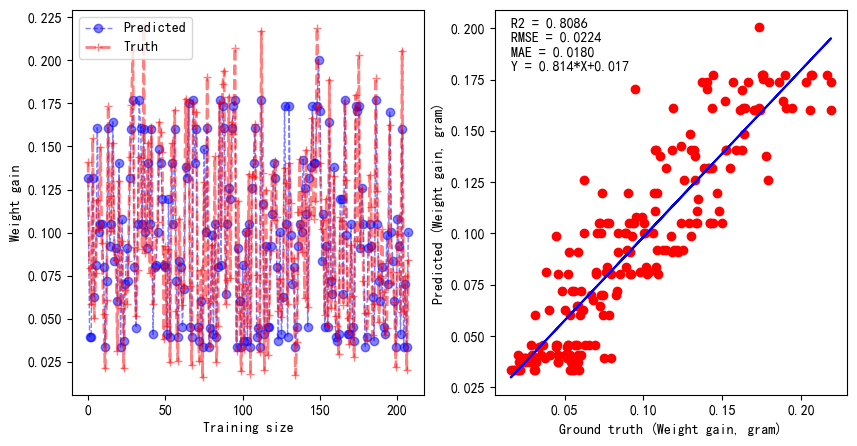

In [191]:
x = [i for i in range(len(y_pred_rf_GWO))]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, y_pred_rf_GWO, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='Truth', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain')

lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(y_pred_rf_GWO.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),y_pred_rf_GWO.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(y_pred_rf_GWO.tolist()), f'R2 = {r2_score(test_Y,y_pred_rf_GWO):.4f}')
ax[1].text(min(test_Y.tolist()), max(y_pred_rf_GWO.tolist())-0.007, f'RMSE = {np.sqrt(mean_squared_error(test_Y,y_pred_rf_GWO)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_rf_GWO.tolist())-0.014, f'MAE = {mean_absolute_error(test_Y,y_pred_rf_GWO):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_rf_GWO.tolist())-0.021, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
plt.savefig('d:/增量预测/预测结果图_RF_GWO.svg',format='svg',dpi= 1200)
plt.show()   ####Visualize GWO adjusted RF model

**<font color = blue size=5>
2.4. SVR
</font>**

In [204]:
svr_model = SVR()
svr_model.fit(train_X, train_Y)
y_pred = svr_model.predict(test_X)

In [205]:
print('SVR模型——R2：{}'.format(r2_score(test_Y,y_pred)))
print('SVR模型——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,y_pred))))
print('SVR模型——MAE：{}'.format(mean_absolute_error(test_Y,y_pred)))

SVR模型——R2：-0.15347651474146118
SVR模型——RMSE：0.0549386559380661
SVR模型——MAE：0.046951672239702945


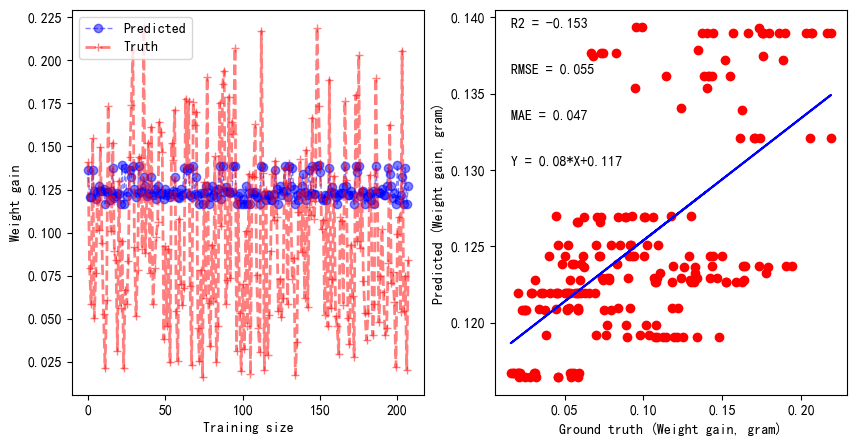

In [206]:
x = [i for i in range(len(y_pred))]
# 绘制图像
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, y_pred, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='Truth', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain')

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(y_pred.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),y_pred.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(y_pred.tolist()), f'R2 = {r2_score(test_Y, y_pred):.3f}')
ax[1].text(min(test_Y.tolist()), max(y_pred.tolist())-0.003, f'RMSE = {np.sqrt(mean_squared_error(test_Y,y_pred)):.3f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred.tolist())-0.006, f'MAE = {mean_absolute_error(test_Y,y_pred):.3f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred.tolist())-0.009, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
plt.savefig('d:/增量预测/预测结果图_SVR.svg',format='svg')
plt.show()

#########Considering that SVR model showed poor performance to the weight gain data, further optimization steps (Grid search and GWO algorithm) was not performed

**<font color = blue size=5>
2.5. Linear regression
</font>**

In [111]:
model = LinearRegression()

In [112]:
model.fit(train_X, train_Y)

LinearRegression()

In [113]:
lr_pred = model.predict(test_X)

In [114]:
print('Linear regression model——R2：{}'.format(r2_score(test_Y,lr_pred)))
print('Linear regression model——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,lr_pred))))
print('Linear regression model——MAE：{}'.format(mean_absolute_error(test_Y,lr_pred)))


Linear regression model——R2：0.43574572846755655
Linear regression model——RMSE：0.03842475258366774
Linear regression model——MAE：0.031201263535750694


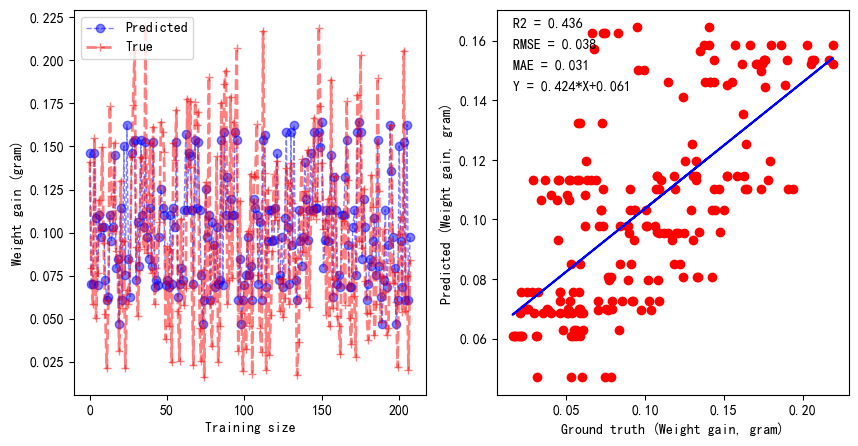

In [115]:
x = [i for i in range(len(lr_pred))]
# 绘制图像
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, lr_pred, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='True', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain (gram)')

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(lr_pred.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),lr_pred.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(lr_pred.tolist()), f'R2 = {r2_score(test_Y, lr_pred):.3f}')
ax[1].text(min(test_Y.tolist()), max(lr_pred.tolist())-0.007, f'RMSE = {np.sqrt(mean_squared_error(test_Y,lr_pred)):.3f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(lr_pred.tolist())-0.014, f'MAE = {mean_absolute_error(test_Y,lr_pred):.3f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(lr_pred.tolist())-0.021, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
plt.savefig('d:/增量预测/预测结果图_LR.svg',format='svg')
plt.show()
#########Considering that LR model showed poor performance to the weight gain data, further optimization steps (Grid search and GWO algorithm) was not performed

**<font color = blue size=5>
2.6.1 XGBoost (default)
</font>**

In [192]:
xgb = XGBRegressor(nthread=10)
xgb.fit(train_X, train_Y)
predict1 = xgb.predict(test_X)

In [193]:
print('XGBOOST——R2：{}'.format(r2_score(test_Y,predict1)))
print('XGBOOST——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,predict1))))
print('XGBOOST——MAE：{}'.format(mean_absolute_error(test_Y,predict1)))

XGBOOST——R2：0.8082371640191202
XGBOOST——RMSE：0.02240040518032108
XGBOOST——MAE：0.018073472259540715


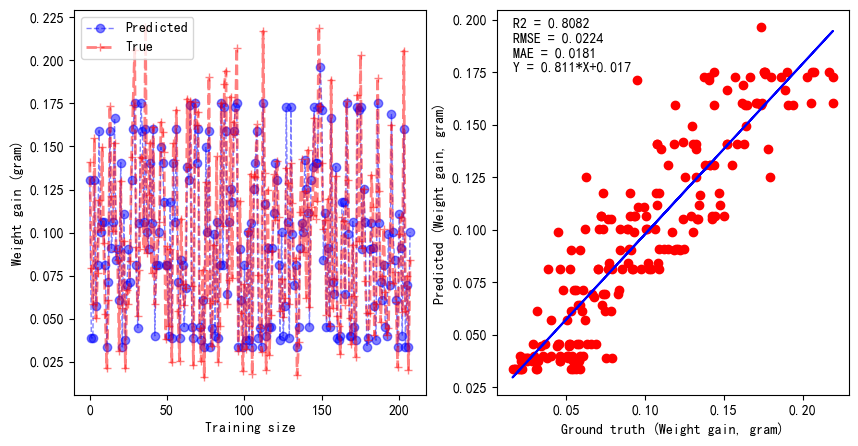

In [194]:
x = [i for i in range(len(predict1))]
##Visualization
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, predict1, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='True', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain (gram)')

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(predict1.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),predict1.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(predict1.tolist()), f'R2 = {r2_score(test_Y, predict1):.4f}')
ax[1].text(min(test_Y.tolist()), max(predict1.tolist())-0.007, f'RMSE = {np.sqrt(mean_squared_error(test_Y,predict1)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(predict1.tolist())-0.014, f'MAE = {mean_absolute_error(test_Y,predict1):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(predict1.tolist())-0.021, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
#plt.savefig('d:/增量预测/预测结果图_XGBoost.svg',format='svg')
plt.show()

**<font color = blue size=5>
2.6.2 XGBoost model (adjusted by Grid search)
</font>**

In [216]:
param_grid = {'max_depth': np.arange(3,100,30),
       'learning_rate':[ 0.01,0.1,0.3,0.8,1],
              'n_estimators':np.arange(10,3000,500)
        }

In [217]:
xgb = XGBRegressor(nthread=10)
reg = GridSearchCV(xgb,
                   param_grid,
                   scoring='r2',
                   cv=3,verbose = 1).fit(train_X,train_Y)

best_alpha = reg.best_params_
best_score = reg.best_score_

Fitting 3 folds for each of 120 candidates, totalling 360 fits


In [218]:
best_alpha

{'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 510}

In [219]:
best_score

0.705641686983579

In [220]:
xgb = XGBRegressor(nthread=10,learning_rate= 0.3, max_depth= 50, n_estimators=200)
xgb.fit(train_X, train_Y)
predict2 = xgb.predict(test_X)

In [221]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print('XGBOOST模型——R2：{}'.format(r2_score(test_Y,predict1)))
print('XGBOOST模型——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,predict1))))
print('XGBOOST模型——MAE：{}'.format(mean_absolute_error(test_Y,predict1)))

XGBOOST模型——R2：0.8082371640191202
XGBOOST模型——RMSE：0.02240040518032108
XGBOOST模型——MAE：0.018073472259540715


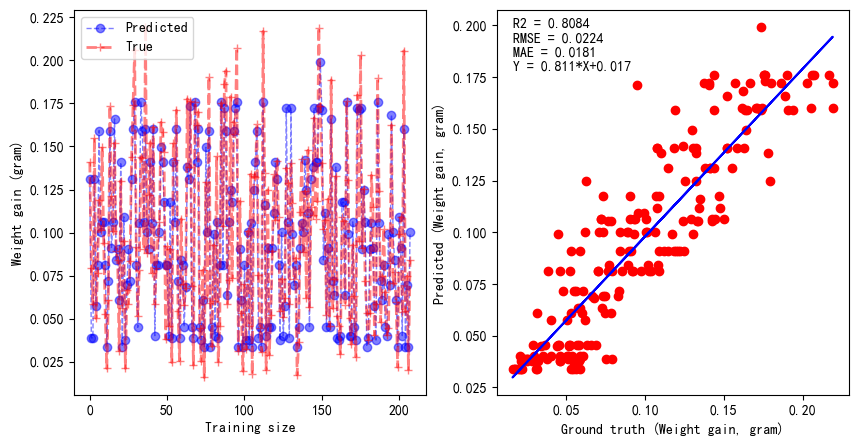

In [222]:
x = [i for i in range(len(predict2))]
# 绘制图像
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, predict2, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='True', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain (gram)')

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(predict2.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),predict2.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(predict2.tolist()), f'R2 = {r2_score(test_Y, predict2):.4f}')
ax[1].text(min(test_Y.tolist()), max(predict2.tolist())-0.007, f'RMSE = {np.sqrt(mean_squared_error(test_Y,predict2)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(predict2.tolist())-0.014, f'MAE = {mean_absolute_error(test_Y,predict2):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(predict2.tolist())-0.021, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
#plt.savefig('d:/增量预测/预测结果图_XGBoost.svg',format='svg')
plt.show()

**<font color = blue size=5>
2.6.3 XGBoost model (Optimised by GWO algorithm, learning_rate 0.1-1)
</font>**

In [229]:
#######learning_rate of XGBoost model is a fload type data (from 0.01-1), int() can't be used for this parameter. re-write the GWO algorithm for XGBoost model.
# GWO initialization
def initial(pop, dim, ub, lb):
    X = np.zeros([pop, dim])
    for i in range(pop):
        for j in range(dim):
            X[i, j] = lb[j] + (ub[j] - lb[j]) * random.random()  # Random initialization
    return X

def BorderCheck(X, ub, lb, pop, dim):
    # Ensure that all individuals are within the specified bounds
    for i in range(pop):
        for j in range(dim):
            if X[i, j] < lb[j]:
                X[i, j] = lb[j]
            elif X[i, j] > ub[j]:
                X[i, j] = ub[j]
    return X

def CaculateFitness(X, fun, train_X, test_X, train_Y, test_Y):
    pop = X.shape[0]
    fitness = np.zeros([pop, 1])
    for i in range(pop):
        fitness[i] = fun(X[i, :], train_X, test_X, train_Y, test_Y)
    return fitness

def SortFitness(Fit):
    fitness = np.sort(Fit, axis=0)
    index = np.argsort(Fit, axis=0)
    return fitness, index

def SortPosition(X, index):
    Xnew = np.zeros(X.shape)
    for i in range(X.shape[0]):
        Xnew[i, :] = X[index[i], :]
    return Xnew

# GWO algorithm
def GWO(pop, dim, lb, ub, MaxIter, fun, train_X, test_X, train_Y, test_Y):
    Alpha_pos = np.zeros([1, dim])
    Alpha_score = float("-inf")
    Beta_pos = np.ones([1, dim])
    Beta_score = float("-inf")
    Delta_pos = np.ones([1, dim])
    Delta_score = float("-inf")

    X = initial(pop, dim, ub, lb)  
    fitness = CaculateFitness(X, fun, train_X, test_X, train_Y, test_Y)  
    indexBest = np.argmax(fitness)
    GbestScore = copy.copy(fitness[indexBest])
    GbestPositon = np.zeros([1, dim])
    GbestPositon[0, :] = copy.copy(X[indexBest, :])
    Curve = np.zeros([MaxIter, 1])

    for t in range(MaxIter):
        for i in range(pop):
            fitValue = fun(X[i, :], train_X, test_X, train_Y, test_Y)
            if fitValue > Alpha_score:
                Alpha_score = copy.copy(fitValue)
                Alpha_pos[0, :] = copy.copy(X[i, :])

            if fitValue < Alpha_score and fitValue > Beta_score:
                Beta_score = copy.copy(fitValue)
                Beta_pos[0, :] = copy.copy(X[i, :])

            if fitValue < Alpha_score and fitValue < Beta_score and fitValue > Delta_score:
                Delta_score = copy.copy(fitValue)
                Delta_pos[0, :] = copy.copy(X[i, :])

        a = 2 - t * (2 / MaxIter)
        for i in range(pop):
            for j in range(dim):
                r1 = random.random()
                r2 = random.random()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2

                D_alpha = np.abs(C1 * Alpha_pos[0, j] - X[i, j])
                X1 = Alpha_pos[0, j] - A1 * D_alpha

                r1 = random.random()
                r2 = random.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2

                D_beta = np.abs(C2 * Beta_pos[0, j] - X[i, j])
                X2 = Beta_pos[0, j] - A2 * D_beta

                r1 = random.random()
                r2 = random.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_beta = np.abs(C3 * Delta_pos[0, j] - X[i, j])
                X3 = Delta_pos[0, j] - A3 * D_beta

                X[i, j] = (X1 + X2 + X3) / 3

        X = BorderCheck(X, ub, lb, pop, dim) 
        fitness = CaculateFitness(X, fun, train_X, test_X, train_Y, test_Y)  
        indexBest = np.argmax(fitness)
        if fitness[indexBest] >= GbestScore:  
            GbestScore = copy.copy(fitness[indexBest])
            GbestPositon[0, :] = copy.copy(X[indexBest, :])
        Curve[t] = GbestScore

    return GbestScore, GbestPositon, Curve

def fun1(X, train_X, test_X, train_Y, test_Y):
    # Extract hyperparameters from X
    learning_rate = X[0]
    max_depth = int(X[1])
    n_estimators = int(X[2])

    # Train XGBoost model with the given hyperparameters
    model = XGBRegressor(learning_rate=learning_rate, max_depth=max_depth, n_estimators=n_estimators)
    model.fit(train_X, train_Y)
    
    # Predict and calculate R2 score
    y_pred = model.predict(test_X)
    r2 = r2_score(test_Y, y_pred)

    return r2 

# Main of GWO algorithm
if __name__ == "__main__":

    # Set GWO parameters
    pop = 10  # Population size
    MaxIter = 500  # Maximum number of iterations
    dim = 3  # Dimension (number of parameters to optimize: learning_rate, max_depth, n_estimators)
    lb = np.array([0.1, 3, 30])  # Lower bounds for each parameter
    ub = np.array([1, 100, 3000])  # Upper bounds for each parameter, set learning_rate from 0.1 to 1

    # Run GWO for XGBoost parameter tuning
    GbestScore, GbestPositon, Curve = GWO(pop, dim, lb, ub, MaxIter, fun1, train_X, test_X, train_Y, test_Y)
    
    # Print the best result
    print('Best parameters found by GWO:', GbestPositon)
    print('Best R2 score:', -GbestScore)

###output[learning_rate, max_depth, n_estimators]
###output[-R2]

Best parameters found by GWO: [[5.21205970e-01 3.21166545e+00 2.23524960e+03]]
Best R2 score: [-0.80927306]


In [230]:
####Generate GWO optimised XGboost model
print(GbestPositon[0][0])
print(int(GbestPositon[0][1]))
print(int(GbestPositon[0][2]))
XGBoost_GWO_model = XGBRegressor(nthread=10,learning_rate=GbestPositon[0][0],max_depth= int(GbestPositon[0][1]),n_estimators=int(GbestPositon[0][2]))                                 
XGBoost_GWO_model.fit(train_X, train_Y)
y_pred_XGBoost_GWO = XGBoost_GWO_model.predict(test_X)

0.521205969877005
3
2235


In [231]:
print('XGBOOST——R2：{}'.format(r2_score(test_Y,y_pred_XGBoost_GWO)))
print('XGBOOST——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,y_pred_XGBoost_GWO))))
print('XGBOOST——MAE：{}'.format(mean_absolute_error(test_Y,y_pred_XGBoost_GWO)))

XGBOOST——R2：0.8092730594303434
XGBOOST——RMSE：0.022339820189577225
XGBOOST——MAE：0.018042207780454914


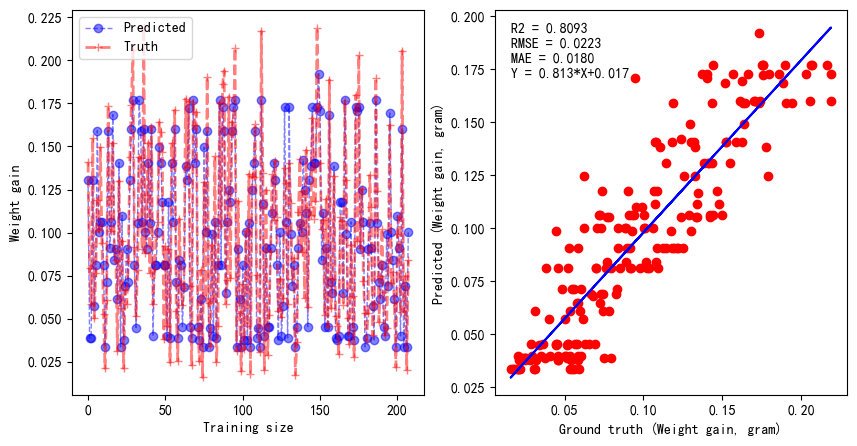

In [233]:
x = [i for i in range(len(y_pred_XGBoost_GWO))]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, y_pred_XGBoost_GWO, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='Truth', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain')

lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(y_pred_XGBoost_GWO.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),y_pred_XGBoost_GWO.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(y_pred_XGBoost_GWO.tolist()), f'R2 = {r2_score(test_Y,y_pred_XGBoost_GWO):.4f}')
ax[1].text(min(test_Y.tolist()), max(y_pred_XGBoost_GWO.tolist())-0.007, f'RMSE = {np.sqrt(mean_squared_error(test_Y,y_pred_XGBoost_GWO)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_XGBoost_GWO.tolist())-0.014, f'MAE = {mean_absolute_error(test_Y,y_pred_XGBoost_GWO):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_XGBoost_GWO.tolist())-0.021, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
plt.savefig('d:/增量预测/预测结果图_XGBoost_GWO.svg',format='svg',dpi= 1200)
XGBoost_GWO_model.save_model("d:/增量预测/xgboost_model.json")
plt.show()   ####Visualize GWO adjusted XGBoost model

**<font color = blue size=5>
2.6.4 XGBoost model (Optimised by GWO algorithm, learning_rate 0.01-0.99)
</font>**

In [164]:
if __name__ == "__main__":    
    # Set GWO parameters
    pop = 10  # Population size
    MaxIter = 500  # Maximum number of iterations
    dim = 3  # Dimension (number of parameters to optimize: learning_rate, max_depth, n_estimators)
    lb = np.array([0.010, 3, 30])  # Lower bounds for each parameter
    ub = np.array([0.099, 100, 3000])  # Upper bounds for each parameter,set learning_rate from 0.01 to 0.099 (if set learning_rate from 0.01 to 1, the GWO code will get fatal error (extremely wrong R2), so do it separately)

    # Run GWO for XGBoost parameter tuning
    GbestScore, GbestPositon, Curve = GWO(pop, dim, lb, ub, MaxIter, fun1, train_X, test_X, train_Y, test_Y)
    
    # Print the best result
    print('Best parameters found by GWO:', GbestPositon)
    print('Best R2 score:', -GbestScore)

    # Plot the convergence curve

Best parameters found by GWO: [[1.13123874e-02 1.07442482e+01 3.94183777e+02]]
Best R2 score: [-0.80908704]


In [170]:
####Generate GWO adjusted XGboost model
print(GbestPositon[0][0])
print(int(GbestPositon[0][1]))
print(int(GbestPositon[0][2]))
XGBoost_GWO_model = XGBRegressor(nthread=10,learning_rate=GbestPositon[0][0],max_depth= int(GbestPositon[0][1]),n_estimators=int(GbestPositon[0][2]))                                 
XGBoost_GWO_model.fit(train_X, train_Y)
y_pred_XGBoost_GWO1 = XGBoost_GWO_model.predict(test_X)

0.011312387385540544
10
394


In [171]:
print('XGBOOST模型——R2：{}'.format(r2_score(test_Y,y_pred_XGBoost_GWO1)))
print('XGBOOST模型——RMSE：{}'.format(np.sqrt(mean_squared_error(test_Y,y_pred_XGBoost_GWO1))))
print('XGBOOST模型——MAE：{}'.format(mean_absolute_error(test_Y,y_pred_XGBoost_GWO1)))

XGBOOST模型——R2：0.8090870365432143
XGBOOST模型——RMSE：0.022350711951972087
XGBOOST模型——MAE：0.018062538649144973


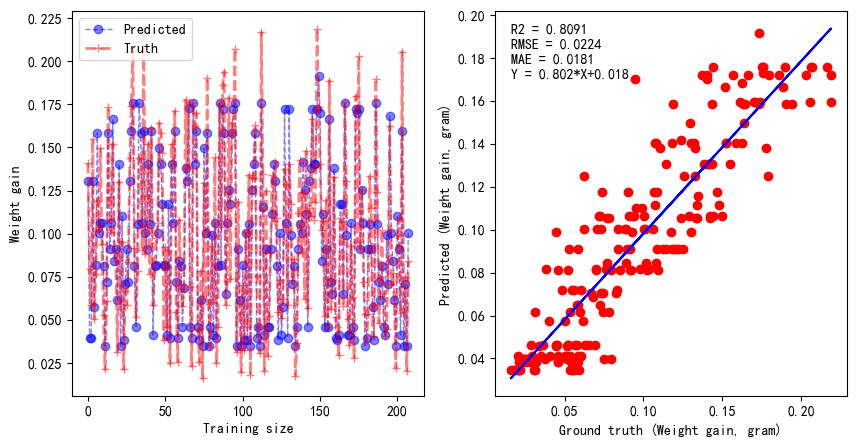

In [172]:
x = [i for i in range(len(y_pred_XGBoost_GWO1))]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(x, y_pred_XGBoost_GWO1, label='Predicted', alpha=0.5, color='blue', linewidth=1, marker='o',
        linestyle='--')
ax[0].plot(x, test_Y.tolist(), label='Truth', alpha=0.5, color='red', linewidth=2, marker='+',
        linestyle='--')
ax[0].legend()
ax[0].set_xlabel('Training size')
ax[0].set_ylabel('Weight gain')

lr = LinearRegression()
lr.fit(np.array(test_Y.tolist()).reshape(-1,1),np.array(y_pred_XGBoost_GWO1.tolist()).reshape(-1,1))
ax[1].scatter(test_Y.tolist(),y_pred_XGBoost_GWO1.tolist(), color = 'red')
ax[1].plot(np.array(test_Y.tolist()), lr.predict(np.array(test_Y.tolist()).reshape(-1,1)),color ='blue')

ax[1].text(min(test_Y.tolist()), max(y_pred_XGBoost_GWO1.tolist()), f'R2 = {r2_score(test_Y,y_pred_XGBoost_GWO1):.4f}')
ax[1].text(min(test_Y.tolist()), max(y_pred_XGBoost_GWO1.tolist())-0.007, f'RMSE = {np.sqrt(mean_squared_error(test_Y,y_pred_XGBoost_GWO1)):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_XGBoost_GWO1.tolist())-0.014, f'MAE = {mean_absolute_error(test_Y,y_pred_XGBoost_GWO1):.4f}', size=10,)
ax[1].text(min(test_Y.tolist()), max(y_pred_XGBoost_GWO1.tolist())-0.021, 'Y = {}*X+{}'.format(round(lr.coef_[0][0],3),round(lr.intercept_[0],3) , size=10,))
ax[1].set_xlabel('Ground truth (Weight gain, gram)')
ax[1].set_ylabel('Predicted (Weight gain, gram)')
#plt.savefig('d:/增量预测/预测结果图_决策树_GWO.svg',format='svg',dpi= 1200)
plt.show()   ####Visualize GWO adjusted XGBoost model

In [173]:
joblib.dump(XGBoost_GWO_model, 'd:/增量预测/model.pkl')
###Save the best model
#########Select the best model for final result (with the highest R2 value and the lowest RMSE and MAE value).

['d:/增量预测/model.pkl']

**<font color = blue size=5>
2.6.4 SHAP analysis of XGBoost model
</font>**

In [174]:
train_X.columns

Index(['C', 'N', 'Vb', 'Vc', 'Fat', 'cellulose'], dtype='object')

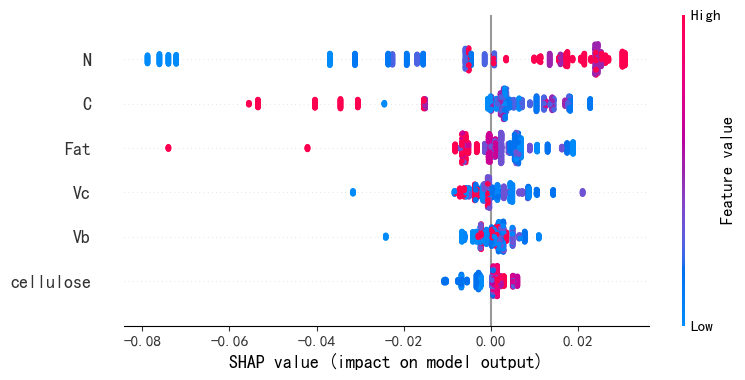

In [175]:
#摘要图
background_adult = shap.maskers.Independent(train_X, max_samples=100)
explainer = shap.Explainer(xgb.predict, background_adult)
shap_values = explainer(train_X)

shap.summary_plot(shap_values, train_X,show=False)
#plt.savefig('d:/增量预测/摘要图.png')

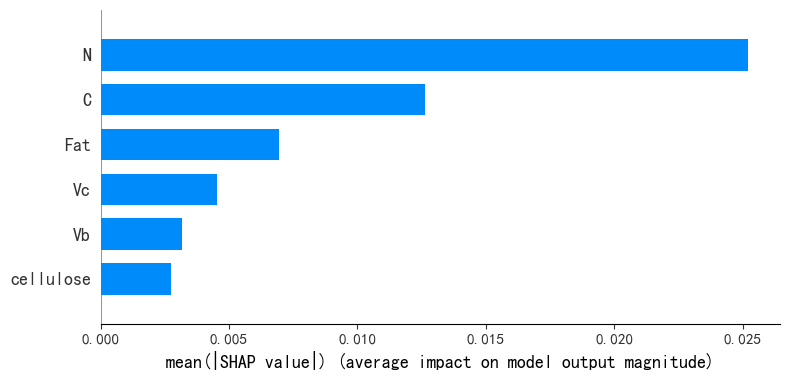

In [176]:
shap.summary_plot(shap_values, train_X, plot_type="bar",show=False)
#plt.savefig('d:/增量预测/特征重要性图.png')

In [177]:
shap.force_plot(shap_values[0,:], train_X.iloc[0,:], matplotlib=True,show=False)
#plt.savefig('d:/增量预测/单实例分析.png')